# Golden Power Network Analysis

**Case Study: EU Regulation 2019/452 ("Golden Power")**

A regulation that, despite being classified as "European Union", actually touches on 15 different legislative domains and cites/is cited by 39 laws spread across seemingly unrelated sectors.

This notebook demonstrates:
1. **Analysis of the problem**: How EuroVoc's a priori classification obscures functional relationships
2. **Visualization solution**: How citation-based clustering reveals true legislative architecture

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import networkx as nx
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from itertools import combinations
from collections import Counter
from networkx.algorithms import community

import warnings
warnings.filterwarnings('ignore')

---
## Part 1: Analysis of the Problem

In this section, we analyze how traditional classification systems (EuroVoc) fragment functionally related legislation across multiple administrative domains.

### 1.1 Data Loading and Network Extraction

In [32]:
# Load data
proc_path = os.path.join('..', 'data', 'processed')
nodes_cleaned = pd.read_csv(os.path.join(proc_path, 'nodes_cleaned.csv'))
edges_cleaned = pd.read_csv(os.path.join(proc_path, 'edges_cleaned.csv'))
edges_weighted = pd.read_csv(os.path.join(proc_path, 'edges_weighted.csv'))
concepts_df = pd.read_csv(os.path.join(proc_path, 'eurovoc_concepts_cleaned.csv'))

# Create concept dictionary
concept_dict = dict(zip(concepts_df['id'].astype(str), concepts_df['label']))

# Rename weight column for consistency with the rest of the notebook
edges_weighted.rename(columns={'final_weight': 'hybrid_thematic_weight'}, inplace=True)

# Define seed regulation (Golden Power)
seed_celex = '32019R0452'
seed_id = seed_celex

# Extract Golden Power ego-network
connections = edges_weighted[(edges_weighted['source'] == seed_id) | (edges_weighted['target'] == seed_id)]
neighbor_ids = set(connections['source']) | set(connections['target'])
golden_power_network = nodes_cleaned[nodes_cleaned['celex'].isin(neighbor_ids)]

print(f"Golden Power Network:")
print(f"  • Connected laws: {len(golden_power_network)}")
print(f"  • Total connections: {len(connections)}")

Golden Power Network:
  • Connected laws: 39
  • Total connections: 40


### 1.2 Distribution of the Network (Bar Chart)

**Problem**: The Golden Power framework is fragmented across 15+ EuroVoc domains, obscuring its thematic unity.

In [33]:
# Parse and count domains
def parse_domains(domains_str):
    """Parse semicolon-separated domains and clean them"""
    if pd.isna(domains_str) or str(domains_str).strip() == '':
        return ['UNKNOWN']
    domains = [d.strip() for d in str(domains_str).split(';') if d.strip()]
    cleaned = [re.sub(r'^\d+\s+', '', d).strip().upper() for d in domains]
    return cleaned if cleaned else ['UNKNOWN']

# Count domain frequencies
domain_counts = Counter()
for domains_str in golden_power_network['domains'].dropna():
    domain_counts.update(parse_domains(domains_str))

# Get top 15 domains
top_domains = domain_counts.most_common(15)
domains = [d[0] for d in top_domains]
counts = [d[1] for d in top_domains]

# Create bar chart
fig = go.Figure(data=[
    go.Bar(
        x=counts,
        y=domains,
        orientation='h',
        marker=dict(
            color=counts,
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(title='Laws')
        )
    )
])

fig.update_layout(
    title='<b>Domain Distribution in Golden Power Network</b><br><sub>Top 15 EuroVoc Domains</sub>',
    xaxis_title='Number of Laws',
    yaxis_title='Domain',
    height=600,
    width=900,
    template='plotly_white',
    yaxis={'categoryorder': 'total ascending'}
)

fig.show()

print("\n Key Insight:")
print("Despite being an 'EU' regulation, Golden Power touches 15+ domains.")
print(f"Top 3 domains: {domains[-1]} ({counts[-1]}), {domains[-2]} ({counts[-2]}), {domains[-3]} ({counts[-3]})")


 Key Insight:
Despite being an 'EU' regulation, Golden Power touches 15+ domains.
Top 3 domains: ENVIRONMENT (1), ECONOMICS (1), TRANSPORT (3)


### 1.3 Confusion Matrix: Domain Overlaps

**Problem**: EuroVoc domains are not "silos" - over 60% of laws have multiple domain assignments, creating ambiguity.

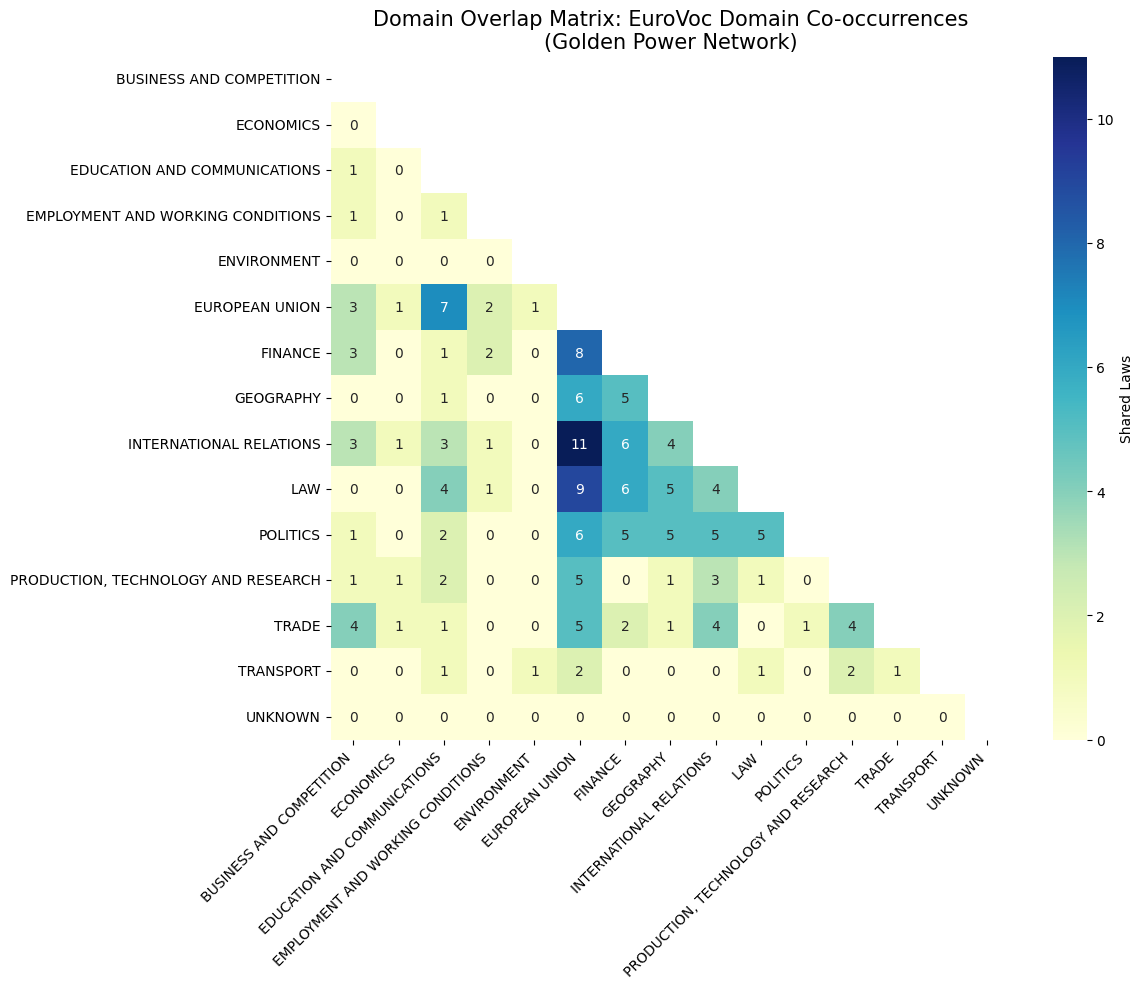


 Key Insight:
Dense co-occurrence matrix proves domains are highly overlapping.
Example: EU ↔ Law (9 laws), EU ↔ Intl Relations (11), Finance ↔ Trade (8)


In [34]:
# Prepare data (exclude UNKNOWN)
dom_series = golden_power_network[golden_power_network['domains'] != '00 UNKNOWN']['domains'].dropna()

def get_domain_list(text):
    if ';' in text:
        return [p.strip() for p in text.split(';')]
    elif ',' in text:
        return [p.strip() for p in text.split(',')]
    else:
        return [text.strip()]

# Calculate co-occurrences
pair_counts = Counter()
all_domains = set()

for entry in dom_series:
    domains = get_domain_list(str(entry))
    all_domains.update(domains)
    for pair in combinations(sorted(domains), 2):
        pair_counts[pair] += 1

# Select top domains for matrix
flat_domains = [d for entry in dom_series for d in get_domain_list(str(entry))]
top_domains_list = pd.Series(flat_domains).value_counts().head(15).index.tolist()
unique_domains = sorted(top_domains_list)

# Build co-occurrence matrix
matrix = pd.DataFrame(0, index=unique_domains, columns=unique_domains)

for (d1, d2), count in pair_counts.items():
    if d1 in unique_domains and d2 in unique_domains:
        matrix.loc[d1, d2] = count
        matrix.loc[d2, d1] = count

# Visualize
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(matrix, dtype=bool))

sns.heatmap(matrix, mask=mask, annot=True, fmt='d', cmap='YlGnBu', 
            cbar_kws={'label': 'Shared Laws'})

plt.title('Domain Overlap Matrix: EuroVoc Domain Co-occurrences\n(Golden Power Network)', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/co_occurrence_matrix_final.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Key Insight:")
print("Dense co-occurrence matrix proves domains are highly overlapping.")
print("Example: EU ↔ Law (9 laws), EU ↔ Intl Relations (11), Finance ↔ Trade (8)")

### 1.4 Build Global Graph and Detect Communities

In [35]:
# Build global weighted graph from edges_weighted
print("Building global weighted graph...")
G_global = nx.from_pandas_edgelist(
    edges_weighted, source='source', target='target',
    edge_attr='hybrid_thematic_weight'
)
print(f"  • Nodes: {G_global.number_of_nodes():,}")
print(f"  • Edges: {G_global.number_of_edges():,}")

# Detect communities using Louvain on weighted graph
print("\nDetecting functional communities (weighted Louvain)...")
clusters_global_list = community.louvain_communities(
    G_global.to_undirected(), weight='hybrid_thematic_weight', seed=42
)

# Create partition dictionary
global_partition = {}
for cluster_id, nodes in enumerate(clusters_global_list):
    for node in nodes:
        global_partition[node] = cluster_id

print(f"  • Communities detected: {len(clusters_global_list)}")

# Extract Golden Power ego-network
print("\nExtracting Golden Power ego-network...")
golden_power_nodes = list(G_global.neighbors(seed_celex)) + [seed_celex]
nodes_golden_power = nodes_cleaned[nodes_cleaned['celex'].isin(golden_power_nodes)].copy()
nodes_golden_power['global_cluster'] = nodes_golden_power['celex'].map(global_partition)

print(f"  • Nodes: {len(nodes_golden_power)}")
print(f"  • Unique communities: {nodes_golden_power['global_cluster'].nunique()}")

# Create subgraph
G_ego = G_global.subgraph(golden_power_nodes).copy()
print(f"  • Edges: {G_ego.number_of_edges()}")

Building global weighted graph...
  • Nodes: 86,217
  • Edges: 212,145

Detecting functional communities (weighted Louvain)...
  • Communities detected: 188

Extracting Golden Power ego-network...
  • Nodes: 39
  • Unique communities: 13
  • Edges: 103


### 1.6 Cross-Community Domain Analysis

**Problem**: Many domains span multiple functional communities, showing that administrative labels don't match functional reality.

In [37]:
# Create Domain-Community Matrix
def create_domain_community_matrix(nodes_df):
    community_domain_data = []
    all_domains = sorted(set([d for domains in nodes_df['domains_list'] for d in domains]))
    
    for cluster_id in sorted(nodes_df['global_cluster'].unique()):
        cluster_data = nodes_df[nodes_df['global_cluster'] == cluster_id]
        cluster_label = cluster_data['macro_area_clean'].iloc[0]
        
        row = {
            'Community': cluster_label,
            'Total Laws': len(cluster_data)
        }
        
        for domain in all_domains:
            count = sum([domain in laws for laws in cluster_data['domains_list']])
            row[domain] = count
        
        community_domain_data.append(row)
    
    matrix_df = pd.DataFrame(community_domain_data)
    
    # Sort columns by frequency
    domain_cols = [col for col in matrix_df.columns if col not in ['Community', 'Total Laws']]
    domain_totals = matrix_df[domain_cols].sum().sort_values(ascending=False)
    sorted_domains = domain_totals.index.tolist()
    
    final_cols = ['Community', 'Total Laws'] + sorted_domains
    return matrix_df[final_cols]

domain_matrix = create_domain_community_matrix(nodes_golden_power)

print("Domain-Community Distribution Matrix:")
print("=" * 80)
print(domain_matrix.to_string(index=False))

# Identify cross-cutting domains
domain_to_communities = {}
for cluster_id in nodes_golden_power['global_cluster'].unique():
    cluster_data = nodes_golden_power[nodes_golden_power['global_cluster'] == cluster_id]
    cluster_label = cluster_data['macro_area_clean'].iloc[0]
    
    for domains in cluster_data['domains_list']:
        for domain in domains:
            if domain not in domain_to_communities:
                domain_to_communities[domain] = set()
            domain_to_communities[domain].add((cluster_id, cluster_label))

print("\n Cross-Cutting Domains (spanning multiple communities):")
print("=" * 80)
cross_cutting = [(d, comms) for d, comms in domain_to_communities.items() if len(comms) > 1]
cross_cutting.sort(key=lambda x: len(x[1]), reverse=True)

for domain, communities in cross_cutting[:5]:
    print(f"\n{domain}: Spans {len(communities)} communities")
    for _, label in sorted(communities):
        n_laws = len(nodes_golden_power[
            (nodes_golden_power['macro_area_clean'] == label) &
            (nodes_golden_power['domains_list'].apply(lambda x: domain in x))
        ])
        print(f"  • {label} ({n_laws} laws)")

# ── Inverse Participation Ratio (IPR) per EuroVoc Domain ──
# IPR = 1 / Σ(p_i²), where p_i is the fraction of a domain's laws in cluster i.
# IPR = 1 → domain is concentrated in one cluster (thematically specific).
# IPR → N_clusters → domain is uniformly spread (thematically "homeless").

print("\n\n" + "=" * 80)
print(" Inverse Participation Ratio (IPR) — Domain Spread Across Communities")
print("=" * 80)

n_clusters = nodes_golden_power['global_cluster'].nunique()

# Collect all unique domains present in the network
all_domains_in_network = sorted(set(
    d for domains in nodes_golden_power['domains_list'] for d in domains
    if d.upper() not in ('UNKNOWN', '')
))

ipr_results = []
for domain in all_domains_in_network:
    # Count how many laws with this domain fall in each cluster
    cluster_counts = {}
    for cluster_id in nodes_golden_power['global_cluster'].unique():
        cluster_data = nodes_golden_power[nodes_golden_power['global_cluster'] == cluster_id]
        count = sum(domain in laws for laws in cluster_data['domains_list'])
        if count > 0:
            cluster_counts[cluster_id] = count
    
    total = sum(cluster_counts.values())
    if total == 0:
        continue
    
    # Calculate IPR
    p_squared_sum = sum((c / total) ** 2 for c in cluster_counts.values())
    ipr = 1.0 / p_squared_sum if p_squared_sum > 0 else 0
    
    ipr_results.append({
        'Domain': domain,
        'Total Laws': total,
        'Clusters Spanned': len(cluster_counts),
        'IPR': round(ipr, 2),
        'Max Possible IPR': n_clusters
    })

ipr_df = pd.DataFrame(ipr_results).sort_values('IPR', ascending=False)

print(f"\nMax possible IPR (uniform spread across {n_clusters} clusters) = {n_clusters:.1f}")
print(f"Min IPR (fully concentrated in 1 cluster) = 1.0\n")
print(ipr_df.to_string(index=False))

# Highlight the most "homeless" domains
high_ipr = ipr_df[ipr_df['IPR'] > 1.5]
if not high_ipr.empty:
    print(f"\n Key Finding: {len(high_ipr)} domain(s) with IPR > 1.5 (high cross-cutting spread):")
    for _, row in high_ipr.iterrows():
        print(f"  • {row['Domain']}: IPR = {row['IPR']} across {row['Clusters Spanned']} clusters")
    print("  → These domains provide near-zero thematic specificity under EuroVoc classification.")

Domain-Community Distribution Matrix:
                                                             Community  Total Laws  EUROPEAN UNION  UNKNOWN  INTERNATIONAL RELATIONS  TRADE  FINANCE  LAW  EDUCATION AND COMMUNICATIONS  BUSINESS AND COMPETITION  GEOGRAPHY  PRODUCTION, TECHNOLOGY AND RESEARCH  POLITICS  TRANSPORT  EMPLOYMENT AND WORKING CONDITIONS  INDUSTRY  ENVIRONMENT  ECONOMICS  SOCIAL QUESTIONS
                                                  CROSS-CUTTING SECTOR           2               0        2                        0      0        0    0                             0                         0          0                                    0         0          0                                  0         0            0          0                 0
                           POLITICS / BUSINESS AND COMPETITION / TRADE           1               1        0                        1      1        0    0                             1                         1          0          

---
## Part 2: Visualization Solutions

### 2.1 Community-Based Visualization

**Solution**: Group laws by citation-based functional communities, not administrative domains.

In [61]:
"""
LCGraph Refined Visualization
==============================
Implements:
    1. Thematic-gravity community placement (MDS on inter-community weight matrix)
    2. Hierarchical Edge Bundling (Bézier ribbons, width ∝ aggregate weight)
    3. Intra-community edge type colouring (AMENDS=amber, TF-IDF rare=neon-cyan)
    4. Golden Power 'halo' + glowing bundles

Drop-in replacement for the original Plotly block.
Requires: numpy, pandas, scipy, plotly
"""

import numpy as np
import pandas as pd
from scipy.spatial.distance import squareform
from scipy.spatial import procrustes
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 1 — THEMATIC DISTANCE COMMUNITY PLACEMENT
# ═══════════════════════════════════════════════════════════════════════════

def build_inter_community_weight_matrix(nodes_df, edges_df,
                                        cluster_col='global_cluster',
                                        celex_col='celex',
                                        weight_col='hybrid_thematic_weight'):
    """ 
    Build a symmetric matrix W[i,j] = sum of hybrid_thematic_weight for all
    edges crossing from community i to community j.
    Returns: (cluster_ids list, weight matrix ndarray, edge_count matrix)
    """
    cluster_ids = sorted(nodes_df[cluster_col].unique())
    n = len(cluster_ids)
    idx = {c: i for i, c in enumerate(cluster_ids)}
    celex_to_cluster = dict(zip(nodes_df[celex_col], nodes_df[cluster_col]))

    W = np.zeros((n, n))
    C = np.zeros((n, n), dtype=int)     # edge count

    for _, row in edges_df.iterrows():
        sc = celex_to_cluster.get(row['source'])
        tc = celex_to_cluster.get(row['target'])
        if sc is None or tc is None or sc == tc:
            continue
        w = float(row.get(weight_col, 1.0))
        i, j = idx[sc], idx[tc]
        W[i, j] += w
        W[j, i] += w
        C[i, j] += 1
        C[j, i] += 1

    return cluster_ids, W, C


def distribute_communities_radially(cluster_ids, seed_cluster, radius=100.0):
    """
    Guarantees no overlaps by placing clusters in a perfect circle 
    around the Golden Power seed.
    """
    pos = {seed_cluster: (0.0, 0.0)}
    others = [c for c in cluster_ids if c != seed_cluster]
    
    for i, cid in enumerate(others):
        angle = (2 * np.pi * i) / len(others)
        pos[cid] = (radius * np.cos(angle), radius * np.sin(angle))
    return pos


def compute_community_radii(nodes_df, cluster_col='global_cluster', alpha=0.52, base=3.5, scale=0.85):
    """
    Calculates bubble size. 
    Added 'scale' parameter to reduce circle size relative to the canvas.
    """
    return {
        c: (base + (int((nodes_df[cluster_col] == c).sum()) ** alpha)) * scale
        for c in nodes_df[cluster_col].unique()
    }


def enforce_non_overlap(community_pos, radii, max_iter=1000, lr=0.5):
    """
    Stronger repulsion pass to eliminate overlaps.
    Increased max_iter from 300 to 1000 and lr (learning rate) to 0.5.
    """
    ids = list(community_pos.keys())
    pos = {k: np.array(v, dtype=float) for k, v in community_pos.items()}

    for _ in range(max_iter):
        moved = False
        for i in range(len(ids)):
            for j in range(i + 1, len(ids)):
                a, b = ids[i], ids[j]
                delta = pos[a] - pos[b]
                dist = np.linalg.norm(delta) + 1e-9
                
                min_dist = radii[a] + radii[b] + 15.0
                
                if dist < min_dist:
                    push = (min_dist - dist) * lr
                    direction = delta / dist
                    pos[a] += direction * push * 0.5
                    pos[b] -= direction * push * 0.5
                    moved = True
        if not moved:
            break

    return {k: (float(v[0]), float(v[1])) for k, v in pos.items()}


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 2 — BOUNDED FRUCHTERMAN-REINGOLD (node placement within community)
# ═══════════════════════════════════════════════════════════════════════════

def bounded_fruchterman_reingold(nodes, edges, cx, cy, radius,
                                 iterations=80, k_scale=1.2, seed=42):
    rng = np.random.default_rng(seed)
    if len(nodes) == 0:
        return {}
    if len(nodes) == 1:
        return {nodes[0]: (cx, cy)}

    angles = rng.uniform(0, 2 * np.pi, len(nodes))
    rs = rng.uniform(0, radius * 0.75, len(nodes))
    pos = {n: np.array([cx + rs[i] * np.cos(angles[i]),
                        cy + rs[i] * np.sin(angles[i])])
                        for i, n in enumerate(nodes)}

    k = k_scale * radius / max(np.sqrt(len(nodes)), 1)
    fa = lambda d: d * d / k
    fr = lambda d: k * k / d if d > 0 else 0
    temp = radius * 0.5
    cooling = temp / (iterations + 1)

    adj = {n: set() for n in nodes}
    for u, v in edges:
        if u in adj and v in adj:
            adj[u].add(v); adj[v].add(u)

    node_list = list(nodes)
    for _ in range(iterations):
        disp = {n: np.zeros(2) for n in node_list}
        # Repulsion
        for i, u in enumerate(node_list):
            for v in node_list[i+1:]:
                delta = pos[u] - pos[v]
                dist = np.linalg.norm(delta) + 1e-6
                f = fr(dist) / dist
                disp[u] += f * delta
                disp[v] -= f * delta
        # Attraction
        for u, v in edges:
            if u not in pos or v not in pos: continue
            delta = pos[u] - pos[v]
            dist = np.linalg.norm(delta) + 1e-6
            f = fa(dist) / dist
            disp[u] -= f * delta
            disp[v] += f * delta
        # Apply + clip to circle
        for n in node_list:
            d = disp[n]
            dn = np.linalg.norm(d)
            if dn > 0:
                pos[n] = pos[n] + d / dn * min(dn, temp)
            centre = np.array([cx, cy])
            from_c = pos[n] - centre
            dist_c = np.linalg.norm(from_c)
            if dist_c > radius * 0.90:
                pos[n] = centre + from_c / dist_c * radius * 0.90
        temp = max(temp - cooling, 0.01)

    return {n: (float(pos[n][0]), float(pos[n][1])) for n in node_list}


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 3 — HIERARCHICAL EDGE BUNDLING (Bézier ribbons)
# ═══════════════════════════════════════════════════════════════════════════

def bezier_quadratic(p0, p1, p2, n_points=60):
    """Quadratic Bézier curve: p0 -> control p2 -> p1"""
    t = np.linspace(0, 1, n_points)
    x = (1-t)**2 * p0[0] + 2*(1-t)*t * p2[0] + t**2 * p1[0]
    y = (1-t)**2 * p0[1] + 2*(1-t)*t * p2[1] + t**2 * p1[1]
    return x, y


def bundle_control_point_offset(p0, p1, bundle_pull=0.12): # Lowered pull for straighter lines
    mid = (p0 + p1) / 2
    vec = p1 - p0
    perp = np.array([-vec[1], vec[0]])
    perp = perp / (np.linalg.norm(perp) + 1e-9)
    # Pushes the curve further out to prevent central "clumping"
    ctrl = mid + bundle_pull * (np.array([0.0, 0.0]) - mid) + (perp * 15.0) 
    return ctrl


def blend_colors_hex(hex1, hex2, t=0.5):
    """Linear blend between two hex colours."""
    def h2r(h): return tuple(int(h.lstrip('#')[i:i+2], 16) for i in (0, 2, 4))
    r1, g1, b1 = h2r(hex1)
    r2, g2, b2 = h2r(hex2)
    r = int(r1 + (r2-r1)*t)
    g = int(g1 + (g2-g1)*t)
    b = int(b1 + (b2-b1)*t)
    return f'rgb({r},{g},{b})'


def build_heb_traces(cluster_ids, community_pos, W, C, cluster_colors,
                     seed_cluster_id, radii,
                     min_bundle_width=0.8, max_bundle_width=18.0,
                     min_show_weight=0.05, bundle_pull=0.28,
                     n_bundle_points=80):
    """
    Build Plotly Scatter traces for Hierarchical Edge Bundling.
    Each bundle trace carries legendgroup tags for both endpoint communities
    so that hiding a community in the legend also hides its bundles.

    Returns list of (ci, cj, go.Scatter) tuples so the caller can set
    legendgroup correctly.
    """
    traces = []     # list of (ci, cj, trace)
    n = len(cluster_ids)
    w_vals = W[W > 0]
    if len(w_vals) == 0:
        return traces
    global_max = w_vals.max()
    global_min = w_vals.min()

    def scale_width(w):
        if global_max == global_min:
            return (min_bundle_width + max_bundle_width) / 2
        t = (w - global_min) / (global_max - global_min)
        return min_bundle_width + t * (max_bundle_width - min_bundle_width)

    idx = {c: i for i, c in enumerate(cluster_ids)}

    for i in range(n):
        for j in range(i+1, n):
            ci, cj = cluster_ids[i], cluster_ids[j]
            w = W[i, j]
            if w < min_show_weight * global_max:
                continue

            p0 = np.array(community_pos[ci])
            p1 = np.array(community_pos[cj])

            # Offset start/end to community edge, not centre
            direction = p1 - p0
            dist = np.linalg.norm(direction) + 1e-9
            p0_edge = p0 + direction / dist * radii[ci]
            p1_edge = p1 - direction / dist * radii[cj]

            # Offset start/end with a gap (e.g., 3.5 units) to clearly show bubble boundaries
            terminal_gap = 3.5
            p0_edge = p0 + direction / dist * (radii[ci] + terminal_gap)
            p1_edge = p1 - direction / dist * (radii[cj] + terminal_gap)

            # Sharpen the curves: Move the control point further out
            ctrl = bundle_control_point_offset(p0_edge, p1_edge, bundle_pull=0.08)
            bx, by = bezier_quadratic(p0_edge, p1_edge, ctrl, n_bundle_points)
            
            # Color: blend the two community colours
            base_color = blend_colors_hex(cluster_colors[ci], cluster_colors[cj], 0.5)

            involves_seed = (ci == seed_cluster_id or cj == seed_cluster_id)
            line_width = scale_width(w)

            if involves_seed:
                # Glow effect: draw 3 layers (wide dim -> narrow bright)
                glow_layers = [
                    (line_width * 2.8, 0.08, 'rgba(220,80,30,{a})'),
                    (line_width * 1.6, 0.18, 'rgba(220,110,40,{a})'),
                    (line_width, 0.85, 'rgba(210,60,10,{a})'),
                    ]
                for lw, alpha_val, color_tmpl in glow_layers:
                    color = color_tmpl.format(a=alpha_val)
                    traces.append((ci, cj, go.Scatter(
                        x=list(bx) + [None], y=list(by) + [None],
                        mode='lines',
                        line=dict(width=lw, color=color, shape='spline'),
                        hoverinfo='none', showlegend=False
                    )))
                # Hover ribbon (invisible wide area to catch hover)
                hover_text = (
                    f"<b>Golden Power Bundle</b><br>"
                    f"Communities: {ci} - {cj}<br>"
                    f"Total thematic weight: {w:.2f}<br>"
                    f"Edge count: {C[i,j]}"
                )
                traces.append((ci, cj, go.Scatter(
                    x=list(bx) + [None], y=list(by) + [None],
                    mode='lines',
                    line=dict(width=line_width + 4, color='rgba(0,0,0,0)'),
                    text=[hover_text] * (len(bx) + 1),
                    hovertemplate='%{text}<extra></extra>',
                    showlegend=False
                )))
            else:
                # Regular bundle
                t_norm = (w - global_min) / (global_max - global_min + 1e-9)
                alpha = 0.25 + 0.40 * t_norm
                traces.append((ci, cj, go.Scatter(
                    x=list(bx) + [None], y=list(by) + [None],
                    mode='lines',
                    line=dict(width=line_width,
                              color=base_color.replace('rgb', 'rgba').replace(')', f',{alpha:.2f})'),
                              shape='spline'),
                    text=[
                        f"<b>Bundle: {ci} - {cj}</b><br>"
                        f"Total weight: {w:.2f} | Edges: {C[i,j]}"
                    ] * (len(bx) + 1),
                    hovertemplate='%{text}<extra></extra>',
                    showlegend=False
                )))

    return traces

# ═══════════════════════════════════════════════════════════════════════════
# SECTION 4 — INTRA-COMMUNITY EDGE COLOURING BY TYPE
# ═══════════════════════════════════════════════════════════════════════════

EDGE_TYPE_STYLES = {
    # Structural / amendment edges -> dark amber/orange, solid, thicker
    'amends': dict(color_base=(200, 120, 0), opacity_scale=0.30, width_mult=0.6), 
    'amending': dict(color_base=(200, 120, 0), opacity_scale=1.0, width_mult=1.4),
    # Implementation / enforcement -> dark teal
    'implements': dict(color_base=(20, 140, 130), opacity_scale=0.90, width_mult=1.0),
    'implemented_by': dict(color_base=( 20, 140, 130), opacity_scale=0.90, width_mult=1.0),
    # Rare TF-IDF / specificity citations -> medium-dark cyan/blue
    'cites': dict(color_base=(0, 150, 200), opacity_scale=0.80, width_mult=0.8),
    'cited_by': dict(color_base=(0, 150, 200), opacity_scale=0.80, width_mult=0.8),
    # Default -> medium grey
    'default': dict(color_base=(110, 110, 110), opacity_scale=0.55, width_mult=0.7),
}

def edge_color_for_type(edge_type, weight, w_min, w_max):
    """
    Returns an rgba string.
    Weight modulates opacity and a slight brightness boost.
    """
    key = str(edge_type).lower() if edge_type else 'default'
    style = EDGE_TYPE_STYLES.get(key, EDGE_TYPE_STYLES['default'])
    r, g, b = style['color_base']
    t = (weight - w_min) / (w_max - w_min + 1e-9)
    alpha = max(0.08, min(0.95, style['opacity_scale'] * (0.2 + 0.8 * t)))
    return f'rgba({r},{g},{b},{alpha:.2f})', style['width_mult']


def build_intra_community_edge_traces(nodes_df, edges_df, pos,
                                      cluster_col='global_cluster',
                                      celex_col='celex'):
    """
    Build one Scatter trace per edge *within* communities,
    colour-coded by edge type.
    Returns list of (cluster_id, go.Scatter) tuples.
    """
    traces = []
    celex_to_cluster = dict(zip(nodes_df[celex_col], nodes_df[cluster_col]))
    w_vals = edges_df['hybrid_thematic_weight'].dropna().values
    w_min = w_vals.min() if len(w_vals) else 0
    w_max = w_vals.max() if len(w_vals) else 1

    for _, row in edges_df.iterrows():
        src, tgt = row['source'], row['target']
        if src not in pos or tgt not in pos: continue
        sc = celex_to_cluster.get(src)
        tc = celex_to_cluster.get(tgt)
        if sc != tc: continue               # inter-community -> handled by HEB

        w = float(row.get('hybrid_thematic_weight', 1.0))
        edge_type = str(row.get('type', 'default')).lower()
        color, wm = edge_color_for_type(edge_type, w, w_min, w_max)
        base_width = 0.4 + (w - w_min) / (w_max - w_min + 1e-9) * 1.6

        x0, y0 = pos[src]; x1, y1 = pos[tgt]
        traces.append((sc, go.Scatter(x=[x0, x1, None], 
                                      y=[y0, y1, None], mode='lines',
                                      line=dict(width=base_width * wm, color=color),
                                      hoverinfo='none', showlegend=False)))
    return traces

# ═══════════════════════════════════════════════════════════════════════════
# SECTION 5 — MAIN FIGURE BUILDER
# ═══════════════════════════════════════════════════════════════════════════

def clean_label(label):
    junk = ["Cross-Cutting Sector", "Law", "Regulation", "Sector", "EUROPEAN UNION"]
    parts = [p.strip() for p in label.split('/') if p.strip() not in junk]
    return " / ".join(parts[:2]) if parts else "Functional Framework"

# Dial down the red 'Amends' lines to 15% opacity so they stay in the background
EDGE_TYPE_STYLES['amends'] = dict(color_base=(200, 120, 0), opacity_scale=0.15, width_mult=0.5)
EDGE_TYPE_STYLES['amending'] = dict(color_base=(200, 120, 0), opacity_scale=0.15, width_mult=0.5)

# Use this logic to generate shorter, descriptive labels
def generate_summary_label(domain_list):
    # Remove generic keywords to find the 'true' functional theme
    junk = ["Cross-Cutting Sector", "Law", "Regulation", "European Union"]
    filtered = [d for d in domain_list if d not in junk]
    if not filtered: return "Inter-Sectoral"
    # Return top 2 unique keywords for a clear summary
    return " / ".join(filtered[:2])

# BEFORE calling build_refined_figure, transform your labels:
processed_labels = {k: generate_summary_label(v.split(' / ')) for k, v in community_labels.items()}

def build_refined_figure(nodes_df, edges_df, community_labels, seed_celex,
                         cluster_col='global_cluster', celex_col='celex',
                         canvas_radius=70.0, bundle_pull=0.30,
                         min_bundle_frac=0.04):

    # Filter out weak 'CITES' links to remove the 'hairball'
    # Only keep the top 20% of citations by weight
# 1. Edge Culling: Filter out weak 'CITES' links to remove the 'hairball'
    # Only keep the top 20% of citations by weight
    cites_only = edges_df[edges_df['type'] == 'cites']
    if not cites_only.empty:
        threshold = cites_only['hybrid_thematic_weight'].quantile(0.8)
        # Filter edges_df for the rest of the drawing process
        edges_df = edges_df[(edges_df['type'] != 'cites') | (edges_df['hybrid_thematic_weight'] >= threshold)]
    
    print("  [1/5] Computing inter-community weight matrix ...")
    cluster_ids, W, C = build_inter_community_weight_matrix(nodes_df, edges_df,
                                                             cluster_col, celex_col)

    print("  [2/5] Radial thematic placement ...")
    celex_to_cluster = dict(zip(nodes_df[celex_col], nodes_df[cluster_col]))
    seed_cluster = celex_to_cluster.get(seed_celex)

    # Use the new Radial Placement
    community_pos = distribute_communities_radially(cluster_ids, seed_cluster, radius=130.0)
    radii = compute_community_radii(nodes_df, cluster_col, scale=0.7) # Smaller bubbles for more air
    
    # Pre-clean the labels for the entire figure
    clean_community_labels = {k: clean_label(v) for k, v in community_labels.items()}

    print("  [3/5] Enforcing non-overlap ...")
    community_pos = enforce_non_overlap(community_pos, radii)

    print("  [4/5] Bounded F-R node placement ...")
    pos = {}
    for cid in cluster_ids:
        subset = nodes_df[nodes_df[cluster_col] == cid]
        node_ids = subset[celex_col].tolist()
        cx, cy = community_pos[cid]
        r = radii[cid]
        intra = [
            (row['source'], row['target'])
            for _, row in edges_df.iterrows()
            if row['source'] in set(node_ids) and row['target'] in set(node_ids)
        ]
        node_pos = bounded_fruchterman_reingold(node_ids, intra, cx, cy, r)
        pos.update(node_pos)

    # Palette (darkened for white background)
    palette = [
        '#1A6BBF','#C93558','#0A8A68','#C97D00','#7B3DBF',
        '#009AA0','#D44D15','#5A8A5A','#C060A0','#0DA882',
        '#B06070','#4A80A0'
    ]
    cluster_colors = {c: palette[i % len(palette)]
                      for i, c in enumerate(cluster_ids)}

    print("  [5] Building Plotly traces ...")
    fig = go.Figure()

    # ── Community bubble traces (Scatter with one huge marker per community)
    # Using traces instead of shapes means legend clicks hide the bubble too.
    print("    -> Community bubble traces ...")
    for cid in cluster_ids:
        cx, cy = community_pos[cid]
        r = radii[cid]
        color = cluster_colors[cid]
        label = community_labels.get(cid, str(cid))
        subset = nodes_df[nodes_df[cluster_col] == cid]
        n_laws = len(subset)
        n_multi = int(subset['is_multidomain'].sum()) if 'is_multidomain' in subset.columns else 0
        is_seed_cluster = (cid == seed_cluster)

        # Bubble: single scatter point with a large circle marker.
        # marker.size is in pixels; we compute an approximate pixel size from
        # the axis-unit radius using a fixed scale factor.
        border_color = 'rgba(210,80,10,0.95)' if is_seed_cluster else color
        border_width = 4 if is_seed_cluster else 2
        fill_opacity = 0.08 if is_seed_cluster else 0.05
        # Convert radius in data units to approximate pixels
        bubble_px = max(30, int(r * 22))

        prefix = '[GP] ' if is_seed_cluster else ''
        hover_bubble = (
            f"<b>{prefix}{label}</b><br>"
            f"{n_laws} laws · {n_multi} multi-domain"
        )
        fig.add_trace(go.Scatter(
            x=[cx], y=[cy],
            mode='markers+text',
            name=f"{prefix}{label} — bubble",
            legendgroup=str(cid),
            showlegend=False,
            marker=dict(
                size=bubble_px,
                color=color,
                opacity=fill_opacity,
                line=dict(color=border_color, width=border_width)
            ),
            text=[f"<b>{prefix}{label}</b><br><sub>{n_laws} laws · {n_multi} multi-domain</sub>"],
            textposition='top center',
            textfont=dict(
                size=13 if not is_seed_cluster else 15,
                color='rgba(210,80,10,1)' if is_seed_cluster else color,
                family='Georgia, serif'
            ),
            hovertemplate=hover_bubble + '<extra></extra>',
            cliponaxis=False
        ))

# ── HEB ribbon traces (center-to-center bundled summary) ─────────────
    print("    -> HEB bundles ...")
    heb_tuples = build_heb_traces(
        cluster_ids, community_pos, W, C, cluster_colors,
        seed_cluster, radii,
        min_bundle_width=1.0, max_bundle_width=16.0,
        min_show_weight=min_bundle_frac,
        bundle_pull=bundle_pull
    )
    import copy as _copy
    for ci, cj, t in heb_tuples:
        # Assign the ribbon to the first community's legend group
        t.legendgroup = str(ci)
        fig.add_trace(t)
        
        # Clone the ribbon and assign it to the second community's legend group
        # This ensures the ribbon is only visible if BOTH communities are enabled
        t2 = _copy.copy(t)
        t2.legendgroup = str(cj)
        fig.add_trace(t2)

# ── Inter-community direct fan lines (node -> community-edge point) ────
    # Instead of node-to-node spaghetti, we draw a thin line from each node
    # to the nearest point on the boundary of the *other* community, then let
    # the HEB ribbon carry the rest of the path. This gives the "connects to
    # real nodes" feel without hairball chaos.
    print("    -> Inter-community fan lines ...")
    w_vals_all = edges_df['hybrid_thematic_weight'].dropna().values
    w_min_g = w_vals_all.min() if len(w_vals_all) else 0
    w_max_g = w_vals_all.max() if len(w_vals_all) else 1

    for _, row in edges_df.iterrows():
        src, tgt = row['source'], row['target']
        if src not in pos or tgt not in pos: continue
        sc = celex_to_cluster.get(src)
        tc = celex_to_cluster.get(tgt)
        if sc is None or tc is None or sc == tc: continue

        w = float(row.get('hybrid_thematic_weight', 1.0))
        t_norm = (w - w_min_g) / (w_max_g - w_min_g + 1e-9)
        alpha = 0.10 + 0.35 * t_norm
        lw = 0.3 + 0.8 * t_norm

        # Determine color: GP connections are orange, others use source community color
        is_gp = (src == seed_celex or tgt == seed_celex)
        if is_gp:
            line_color = f'rgba(210,80,10,{alpha + 0.15:.2f})'
            lw += 0.4
        else:
            r_hex = cluster_colors.get(sc, '#888888')
            def _hex_to_rgb(h):
                h = h.lstrip('#')
                return tuple(int(h[i:i+2], 16) for i in (0, 2, 4))
            rr, gg, bb = _hex_to_rgb(r_hex)
            line_color = f'rgba({rr},{gg},{bb},{alpha:.2f})'

        # Source node -> boundary of target community
        cx_t, cy_t = community_pos[tc]
        sx, sy = pos[src]
        dx, dy = cx_t - sx, cy_t - sy
        d = (dx**2 + dy**2) ** 0.5 + 1e-9
        # End point: on the boundary of the target community circle
        ex = cx_t - dx / d * radii[tc]
        ey = cy_t - dy / d * radii[tc]

        # First trace assigned to source community legendgroup
        fig.add_trace(go.Scatter(
            x=[sx, ex, None], y=[sy, ey, None],
            mode='lines',
            line=dict(width=lw, color=line_color),
            hoverinfo='none', showlegend=False,
            legendgroup=str(sc)
        ))
        # Second trace assigned to target community legendgroup
        fig.add_trace(go.Scatter(
            x=[sx, ex, None], y=[sy, ey, None],
            mode='lines',
            line=dict(width=lw, color=line_color),
            hoverinfo='none', showlegend=False,
            legendgroup=str(tc)
        ))

# ── Intra-community typed edge traces ─────────────────────────────────
    print("    -> Intra-community edges ...")
    intra_tuples = build_intra_community_edge_traces(nodes_df, edges_df, pos,
                                                       cluster_col, celex_col)
    for cid, t in intra_tuples:
        t.legendgroup = str(cid)
        fig.add_trace(t)

    # ── Node traces by community ──────────────────────────────────────────
    print("    -> Node traces ...")
    seed_row    = nodes_df[nodes_df[celex_col] == seed_celex]
    other_nodes = nodes_df[nodes_df[celex_col] != seed_celex]

    for cid in cluster_ids:
        subset = other_nodes[other_nodes[cluster_col] == cid]
        if subset.empty: continue
        color = cluster_colors[cid]

        sizes, bwidths, bcolors, hovers = [], [], [], []
        xs, ys = [], []

        for _, row in subset.iterrows():
            n = row[celex_col]
            if n not in pos: continue
            xs.append(pos[n][0]); ys.append(pos[n][1])

            base = 11
            if row.get('is_multidomain', False):
                sizes.append(base + row.get('num_domains', 1) * 2.5)
                bwidths.append(2.5); bcolors.append('#C8A000')
            else:
                sizes.append(base); bwidths.append(1.0)
                bcolors.append('rgba(255,255,255,0.3)')

            gp_edge = edges_df[
                ((edges_df['source'] == seed_celex) & (edges_df['target'] == n)) |
                ((edges_df['source'] == n) & (edges_df['target'] == seed_celex))
            ]
            gp_w = f"{gp_edge['hybrid_thematic_weight'].iloc[0]:.2f}" if not gp_edge.empty else 'N/A'
            gp_t = gp_edge['type'].iloc[0] if not gp_edge.empty else 'N/A'
            yr   = int(float(row['year'])) if pd.notna(row.get('year')) else 'N/A'
            dom  = row.get('domains_display', '')
            hovers.append(
                f"<b>{row['title']}</b><br><br>"
                f"<b>CELEX:</b> {n}<br><b>Year:</b> {yr}<br><br>"
                f"<b>Community:</b> {community_labels.get(cid, cid)}<br>"
                f"<b>GP Link:</b> {gp_t} (w={gp_w})<br><br>"
                f"<b>Domains ({row.get('num_domains', 0)}):</b><br>{dom}"
            )

        label = community_labels.get(cid, str(cid))
        fig.add_trace(go.Scatter(
            x=xs, y=ys, mode='markers',
            name=f"{label} ({len(xs)})",
            legendgroup=str(cid),
            legendgrouptitle=None,
            marker=dict(
                size=sizes, color=color, opacity=0.90,
                line=dict(width=bwidths, color=bcolors)
            ),
            text=hovers, hovertemplate='%{text}<extra></extra>',
            showlegend=True
        ))

# ── Golden Power seed node — its OWN legend entry ─────────────────────
    # legendgroup='GP' is separate from the community group so it has its own
    # toggle in the legend and is always visible unless explicitly clicked.
    if not seed_row.empty and seed_celex in pos:
        sx, sy = pos[seed_celex]
        fig.add_trace(go.Scatter(
            x=[sx], y=[sy], mode='markers+text',
            name='GOLDEN POWER (EU 2019/452)',
            legendgroup='GP',
            marker=dict(
                size=30, color='#C03000',
                symbol='circle',
                line=dict(width=3, color='#FF9900')
            ),
            text=['GOLDEN POWER'], textposition='top center',
            textfont=dict(size=14, color='#C03000', family='Georgia, serif'),
            hovertemplate=(
                f"<b>{seed_row['title'].iloc[0]}</b><br>"
                "<b>GOLDEN POWER - EU 2019/452</b><br>"
                "<b>FDI Screening Framework</b>"
                "<extra></extra>"
            ),
            showlegend=True
        ))

# ── Legend entries for edge types ─────────────────────────────────────
    # These dummy traces create the visual guide for your citation categories
    for label, style in [
        ('AMENDS (structural)',         dict(color='rgba(200,120,0,0.9)',  width=3)),
        ('IMPLEMENTS (enforcement)',    dict(color='rgba(20,140,130,0.9)', width=2)),
        ('CITES (rare TF-IDF signal)', dict(color='rgba(0,150,200,0.9)',  width=2)),
    ]:
        fig.add_trace(go.Scatter(
            x=[None], y=[None], mode='lines',
            name=label, line=style, showlegend=True
        ))

    # ── Legend entry for HEB bundles ──────────────────────────────────────
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='lines',
        name='Bundle width = thematic weight',
        line=dict(color='rgba(150,150,180,0.8)', width=4),
        showlegend=True
    ))

    # ── Layout ───────────────────────────────────────────────────────────
    print("  [6/6] Finalising layout ...")
    fig.update_layout(
        shapes=shapes,
        title=dict(
            text=(
                "<b>EU Law Thematic Map - LCGraph Refined</b><br>"
                "<sub>Community placement by thematic gravity (MDS) · "
                "Ribbon width = thematic weight between clusters · "
                "Edge colour = citation type</sub>"
            ),
            font=dict(size=20, family='Georgia, serif', color='#711C0E'),
            x=0.5, xanchor='center', y=0.97
        ),
        showlegend=True,
        legend=dict(
            title=dict(text='<b>Communities & Edge Types</b>',
                       font=dict(color='#333333')),
            font=dict(size=11, color='#333333'),
            bgcolor='#FAFAFA',
            bordercolor='rgba(180,140,80,0.5)',
            borderwidth=1,
            x=1.02, y=0.5
        ),
        width=1750, height=1200,
        plot_bgcolor='#FAFAFA',
        paper_bgcolor='#FAFAFA',
        hovermode='closest',
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False,
                   color='#333'),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False,
                   scaleanchor='x', scaleratio=1, color='#333'),
        margin=dict(l=20, r=260, t=80, b=20)
    )
    return fig


fig = build_refined_figure(nodes_golden_power, edges_weighted, processed_labels, seed_celex)

fig.show()

  [1/5] Computing inter-community weight matrix ...
  [2/5] Radial thematic placement ...
  [3/5] Enforcing non-overlap ...
  [4/5] Bounded F-R node placement ...
  [5] Building Plotly traces ...
    -> Community bubble traces ...
    -> HEB bundles ...
    -> Inter-community fan lines ...
    -> Intra-community edges ...
    -> Node traces ...
  [6/6] Finalising layout ...
